# 📈 Linear Regression Models for Next-Year Stock Return Prediction
---

**Objective:** Use firm-level financial data at year *t* to predict stock return at year *t+1*

**Dataset:** ~22,031 rows | ~5,000 tickers | 207 features | 2014–2018

> `Stock_Return` is **pre-labelled** — it already represents the forward-year return.
> No shifting is required.

| Split | Years | Role |
|-------|-------|------|
| Train | 2014–2017 | Model fitting + Optuna tuning |
| Test  | 2018      | Final held-out evaluation |

## Three Experiments
| # | Model | Tuning |
|---|-------|--------|
| 1 | **Baseline** — OLS Linear Regression | None (no hyperparameters) |
| 2 | **Regularised** — Ridge / Lasso / Elastic Net | Optuna (alpha, l1_ratio) |
| 3 | **PCA + Ridge** | Optuna (n_components, alpha) |

## Cell 0 — Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, pearsonr

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import cross_val_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"]       = "DejaVu Sans"

print("✅ All libraries imported.")

✅ All libraries imported.


---
## Step 1 — Load & Combine Datasets

In [3]:


df = pd.read_csv("cleaned_dataset.csv")

print(f"✅ Combined shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Year range      : {df['Year'].min()} – {df['Year'].max()}")
print(f"   Unique tickers  : {df['Ticker'].nunique():,}")
print(f"   Unique sectors  : {df['Sector'].nunique()}")
print()
print("Rows per year:")
print(df['Year'].value_counts().sort_index().to_string())

✅ Combined shape  : 22,031 rows × 207 columns
   Year range      : 2014 – 2018
   Unique tickers  : 4,980
   Unique sectors  : 11

Rows per year:
Year
2014    3787
2015    4114
2016    4783
2017    4957
2018    4390


In [4]:
df[["Ticker", "Year", "Sector", "Stock_Return", "Class", "Return_Direction"]].head(8)

,Ticker,Year,Sector,Stock_Return,Class,Return_Direction
0,PG,2014,Consumer Defensive,-9.3233,0,0
1,VIPS,2014,Consumer Defensive,-25.5122,0,0
2,KR,2014,Consumer Defensive,33.1183,1,1
3,RAD,2014,Consumer Defensive,2.7523,1,1
4,GIS,2014,Consumer Defensive,12.8977,1,1
5,PM,2014,Consumer Defensive,13.9809,1,1
6,KO,2014,Consumer Defensive,5.3394,1,1
7,WMT,2014,Consumer Defensive,-26.6537,0,0


---
## Step 2 — Sort & Inspect the Pre-Labelled Target

`Stock_Return` is already paired with the correct forward return — **no `.shift()` needed**.
`Class` and `Return_Direction` are derived labels and must be excluded as leakage.

In [5]:
df         = df.sort_values(["Ticker", "Year"]).reset_index(drop=True)
TARGET_COL = "Stock_Return"

print(f"Target: {TARGET_COL}")
print("=" * 40)
print(df[TARGET_COL].describe().to_string())

Target: Stock_Return
count   22031.0000
mean        7.6649
std        52.6213
min       -99.9994
25%       -19.5299
50%         3.8351
75%        27.3304
max       975.6097


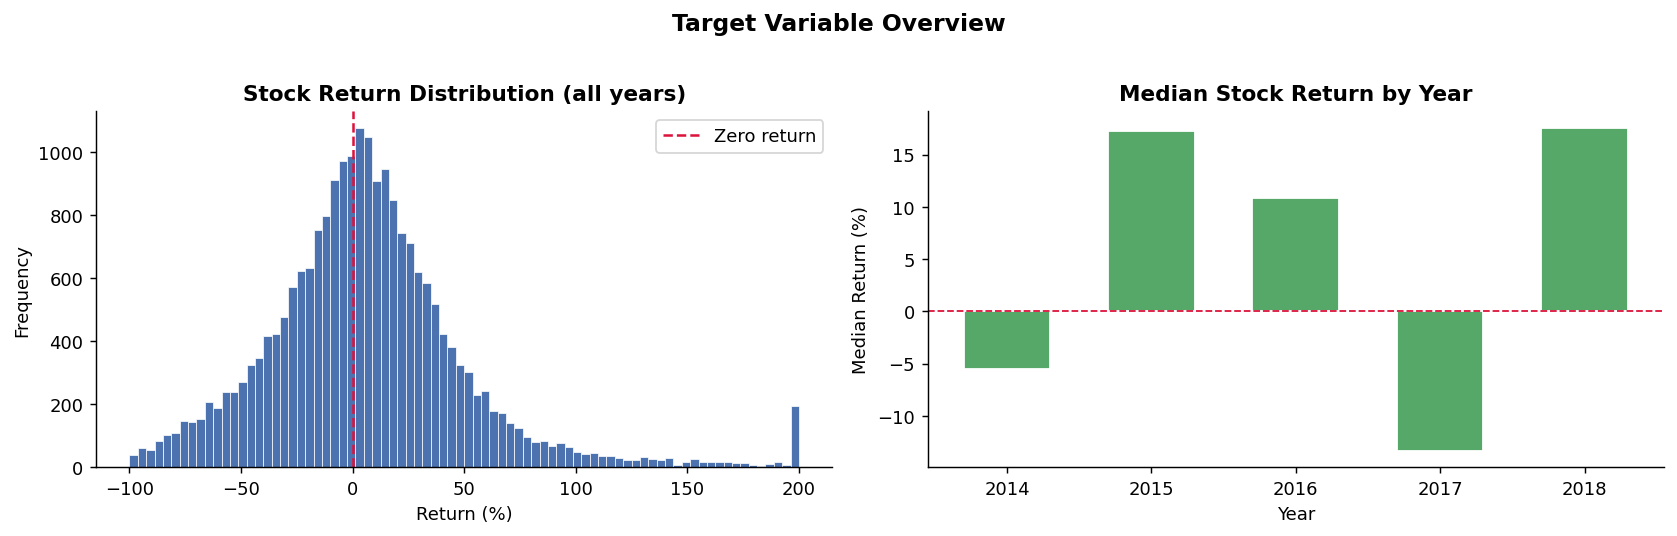

✅ Saved: 00_target_overview.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET_COL].clip(-100, 200), bins=80,
             color="#4C72B0", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="crimson", linestyle="--", linewidth=1.4, label="Zero return")
axes[0].set_title("Stock Return Distribution (all years)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Return (%)"); axes[0].set_ylabel("Frequency")
axes[0].legend()

df.groupby("Year")[TARGET_COL].median().plot(
    kind="bar", ax=axes[1], color="#55A868", edgecolor="white", width=0.6)
axes[1].set_title("Median Stock Return by Year", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Median Return (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=1)

plt.suptitle("Target Variable Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("00_target_overview.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: 00_target_overview.png")

---
## Step 3 — Define Features & Remove Leakage Variables

| Column | Action | Reason |
|--------|--------|--------|
| `Stock_Return` | **Target** | What we predict |
| `Class` | **Exclude** | Derived from target |
| `Return_Direction` | **Exclude** | Derived from target |
| `Ticker`, `Year` | **Exclude** | Identifiers |
| `Sector` | **Categorical feature** | One-hot encoded |

In [7]:
LEAKAGE_COLS     = ["Class", "Return_Direction"]
ID_COLS          = ["Ticker", "Year"]
TARGET_COL       = "Stock_Return"
CATEGORICAL      = ["Sector"]

exclude          = LEAKAGE_COLS + ID_COLS + [TARGET_COL] + CATEGORICAL
NUMERIC_FEATURES = [c for c in df.columns
                    if c not in exclude
                    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f"Numeric features available : {len(NUMERIC_FEATURES)}")
print(f"Categorical features       : {CATEGORICAL}")
print(f"Leakage excluded           : {LEAKAGE_COLS}")

miss = df[NUMERIC_FEATURES].isnull().mean().sort_values(ascending=False)
print(f"\nMissing value summary:")
print(f"  >50% missing : {(miss > 0.50).sum()} features")
print(f"  >20% missing : {(miss > 0.20).sum()} features")
print(f"  >5%  missing : {(miss > 0.05).sum()} features")
print(f"   0%  missing : {(miss == 0.00).sum()} features")

Numeric features available : 201
Categorical features       : ['Sector']
Leakage excluded           : ['Class', 'Return_Direction']

Missing value summary:
  >50% missing : 0 features
  >20% missing : 0 features
  >5%  missing : 0 features
   0%  missing : 201 features


---
## Step 4 — Time-Based Train / Test Split

No random splitting — chronological order is preserved to prevent look-ahead bias.

In [8]:
TRAIN_YEARS = [2014, 2015, 2016, 2017]
TEST_YEAR   = 2018

train_df = df[df["Year"].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
test_df  = df[df["Year"] == TEST_YEAR].copy().reset_index(drop=True)

print("Time-Based Split Summary")
print("=" * 42)
print(f"  Train (2014–2017) : {len(train_df):>6,} rows")
print(f"  Test  (2018)      : {len(test_df):>6,} rows")
print(f"  Total             : {len(train_df)+len(test_df):>6,} rows")

X_train_raw = train_df[NUMERIC_FEATURES + CATEGORICAL]
y_train     = train_df[TARGET_COL].reset_index(drop=True)

X_test_raw  = test_df[NUMERIC_FEATURES + CATEGORICAL]
y_test      = test_df[TARGET_COL].reset_index(drop=True)

CV_SPLITS = [
    ([2014],             2015),
    ([2014, 2015],       2016),
    ([2014, 2015, 2016], 2017),
]
print(f"\nExpanding-window CV folds : {len(CV_SPLITS)}")

Time-Based Split Summary
  Train (2014–2017) : 17,641 rows
  Test  (2018)      :  4,390 rows
  Total             : 22,031 rows

Expanding-window CV folds : 3


---
## Step 5 — Feature Engineering

Five transformations applied sequentially, all **fit on training data only**:

| Step | Transform | Purpose |
|------|-----------|---------|
| 5.1 | **Winsorisation** (1–99th pct) | Clip extreme outliers in financial data |
| 5.2 | **Signed-log** on size vars | Compress right-skewed distributions |
| 5.3 | **Cross-sectional z-score** | Normalise within each year |
| 5.4 | **Sector-relative** | Remove sector-level biases |
| 5.5 | **Δ features** | Capture YoY momentum signals |

In [9]:
# ── 5.1  Winsorisation ────────────────────────────────────────────────────────
print("5.1  Winsorisation (1st–99th pct, fit on train) ...")
winsor_bounds = {}
X_train_w     = train_df[NUMERIC_FEATURES].copy()

for col in NUMERIC_FEATURES:
    lo, hi = X_train_w[col].quantile(0.01), X_train_w[col].quantile(0.99)
    winsor_bounds[col] = (lo, hi)
    X_train_w[col] = X_train_w[col].clip(lo, hi)

X_test_w = test_df[NUMERIC_FEATURES].copy()
for col, (lo, hi) in winsor_bounds.items():
    X_test_w[col] = X_test_w[col].clip(lo, hi)
print("     ✅ Done")

# ── 5.2  Signed-log ───────────────────────────────────────────────────────────
print("5.2  Signed-log transformation ...")
SIZE_VARS = [c for c in ["Revenue","Total assets","Market Cap","Enterprise Value"]
             if c in NUMERIC_FEATURES]

def signed_log(s):
    return np.sign(s) * np.log1p(np.abs(s))

for col in SIZE_VARS:
    X_train_w[col] = signed_log(X_train_w[col])
    X_test_w[col]  = signed_log(X_test_w[col])
print(f"     Applied to : {SIZE_VARS}")
print("     ✅ Done")

5.1  Winsorisation (1st–99th pct, fit on train) ...
     ✅ Done
5.2  Signed-log transformation ...
     Applied to : ['Revenue', 'Total assets', 'Market Cap', 'Enterprise Value']
     ✅ Done


In [10]:
# ── 5.3  Cross-sectional z-score ──────────────────────────────────────────────
print("5.3  Cross-sectional z-score (per year, fit on train) ...")
year_stats = {}
for yr in TRAIN_YEARS:
    mask = (train_df["Year"] == yr)
    year_stats[yr] = {
        "mean": X_train_w[mask].mean(),
        "std":  X_train_w[mask].std().replace(0, 1),
    }

def cs_standardise(X_feat, year_series, stats, fallback=2017):
    out = X_feat.copy()
    for yr in year_series.unique():
        ref  = yr if yr in stats else fallback
        mask = (year_series == yr)
        out.loc[mask] = (X_feat.loc[mask] - stats[ref]["mean"]) / stats[ref]["std"]
    return out

X_train_cs = cs_standardise(X_train_w, train_df["Year"].reset_index(drop=True), year_stats)
X_test_cs  = cs_standardise(X_test_w,  test_df["Year"].reset_index(drop=True),  year_stats)
print("     ✅ Done")

# ── 5.4  Sector-relative adjustment ──────────────────────────────────────────
print("5.4  Sector-relative adjustment ...")
sector_medians = {}
for sec in train_df["Sector"].unique():
    mask = (train_df["Sector"] == sec)
    sector_medians[sec] = X_train_cs[mask].median()

fallback_sec = train_df["Sector"].mode()[0]

def sector_adjust(X_feat, sector_series, medians, fallback):
    out = X_feat.copy()
    for sec in sector_series.unique():
        med  = medians.get(sec, medians[fallback])
        mask = (sector_series == sec)
        out.loc[mask] = X_feat.loc[mask] - med
    return out

X_train_sa = sector_adjust(X_train_cs, train_df["Sector"].reset_index(drop=True),
                            sector_medians, fallback_sec)
X_test_sa  = sector_adjust(X_test_cs,  test_df["Sector"].reset_index(drop=True),
                            sector_medians, fallback_sec)
print("     ✅ Done")

5.3  Cross-sectional z-score (per year, fit on train) ...
     ✅ Done
5.4  Sector-relative adjustment ...
     ✅ Done


In [12]:
# ── 5.5  Δ features ───────────────────────────────────────────────────────────
print("5.5  Delta (YoY change) features ...")
DELTA_PAIRS = {
    "delta_Net_Profit_Margin" : "Net Profit Margin",
    "delta_ROE"               : "ROE",
    "delta_Debt_to_Equity"    : "Debt to Equity",
    "delta_Revenue_Growth"    : "Revenue Growth",
}

for new_col, src_col in DELTA_PAIRS.items():
    if src_col in df.columns:
        df[new_col] = df.groupby("Ticker")[src_col].diff()

DELTA_COLS  = [c for c in DELTA_PAIRS if c in df.columns]
delta_train = df[df["Year"].isin(TRAIN_YEARS)][DELTA_COLS].reset_index(drop=True)
delta_test  = df[df["Year"] == TEST_YEAR][DELTA_COLS].reset_index(drop=True)

X_train_eng = pd.concat([X_train_sa.reset_index(drop=True), delta_train], axis=1)
X_test_eng  = pd.concat([X_test_sa.reset_index(drop=True),  delta_test],  axis=1)

X_train_eng["Sector"] = train_df["Sector"].values
X_test_eng["Sector"]  = test_df["Sector"].values

NUM_FEATS_ENG = NUMERIC_FEATURES + DELTA_COLS
print(f"\n Feature engineering complete.")
print(f"   {len(NUMERIC_FEATURES)} original  +  {len(DELTA_COLS)} delta  =  {len(NUM_FEATS_ENG)} numeric features")

5.5  Delta (YoY change) features ...

 Feature engineering complete.
   201 original  +  4 delta  =  205 numeric features


---
## Step 6 — Feature Selection

Three sequential filters, all derived **from training data only**:

1. **Variance filter** — drop near-constant columns (threshold = 0.01)
2. **Correlation filter** — remove one from any pair with |r| > 0.92
3. **Univariate selection** — keep top 60 features by |Pearson r| with target

In [13]:
# 6.1 Variance filter
print("6.1  Variance filter ...")
_imp  = SimpleImputer(strategy="median")
X_chk = pd.DataFrame(_imp.fit_transform(X_train_eng[NUM_FEATS_ENG]), columns=NUM_FEATS_ENG)

vt            = VarianceThreshold(threshold=0.01)
vt.fit(X_chk)
high_var_feats = [f for f, keep in zip(NUM_FEATS_ENG, vt.get_support()) if keep]
print(f"     Dropped : {len(NUM_FEATS_ENG) - len(high_var_feats):>3}  |  Remaining : {len(high_var_feats)}")

# 6.2 Correlation filter
print("6.2  Correlation filter (|r| > 0.92) ...")
X_hv   = X_chk[high_var_feats]
upper  = X_hv.corr().abs().where(
    np.triu(np.ones((len(high_var_feats), len(high_var_feats))), k=1).astype(bool))
drop_c = [c for c in upper.columns if any(upper[c] > 0.92)]
selected_feats = [f for f in high_var_feats if f not in drop_c]
print(f"     Dropped : {len(drop_c):>3}  |  Remaining : {len(selected_feats)}")

# 6.3 Univariate top-60 by |Pearson r|
print("6.3  Univariate selection (top 60 by |Pearson r|) ...")
X_imp   = X_hv[selected_feats].fillna(X_hv[selected_feats].median())
y_arr   = y_train.values
corr_map = {col: abs(pearsonr(X_imp[col].values, y_arr)[0]) for col in selected_feats}
corr_ser = pd.Series(corr_map).sort_values(ascending=False)
FINAL_NUM_FEATS = corr_ser.head(60).index.tolist()
CAT_FEATS       = ["Sector"]

print(f"     Final feature count : {len(FINAL_NUM_FEATS)} numeric + {len(CAT_FEATS)} categorical")
print(f"\n   Top 15 predictors:")
print(corr_ser.head(15).to_string())

6.1  Variance filter ...
     Dropped :   1  |  Remaining : 204
6.2  Correlation filter (|r| > 0.92) ...
     Dropped :  52  |  Remaining : 152
6.3  Univariate selection (top 60 by |Pearson r|) ...
     Final feature count : 60 numeric + 1 categorical

   Top 15 predictors:
EPS                                      0.1345
freeCashFlowPerShare                     0.0976
Book Value per Share                     0.0728
priceToSalesRatio                        0.0683
EBITDA Margin                            0.0676
returnOnCapitalEmployed                  0.0642
Weighted Average Shares Growth           0.0639
EBIT Margin                              0.0615
Weighted Average Shares Diluted Growth   0.0591
EV to Sales                              0.0573
priceSalesRatio                          0.0567
SG&A Expenses Growth                     0.0549
Revenue                                  0.0502
Asset Growth                             0.0493
Tangible Book Value per Share            0.0484


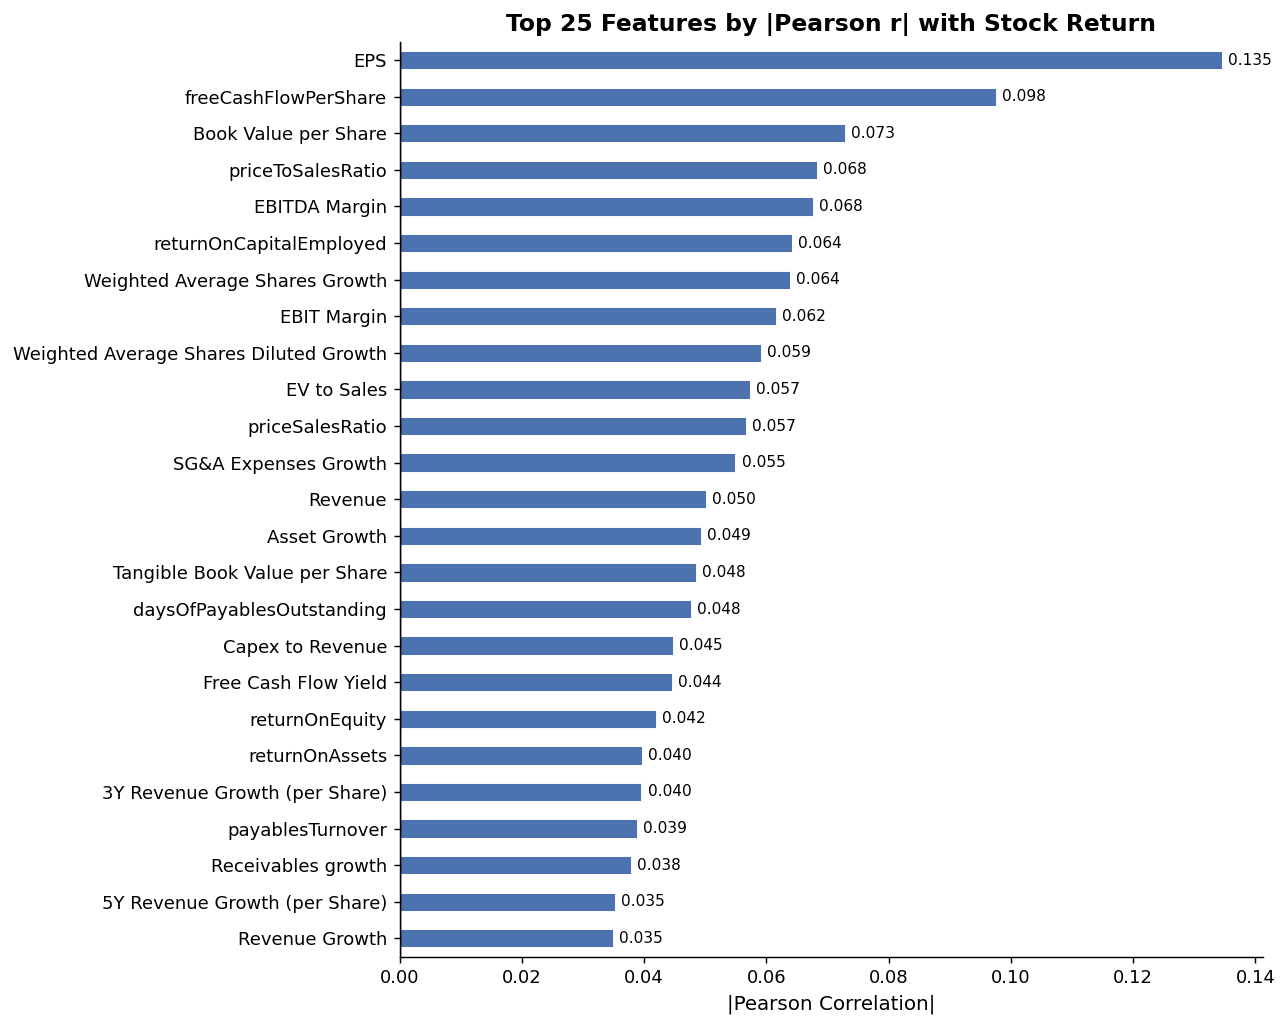

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_ser.head(25).sort_values().plot(
    kind="barh", ax=ax, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.set_title("Top 25 Features by |Pearson r| with Stock Return",
             fontsize=13, fontweight="bold")
ax.set_xlabel("|Pearson Correlation|", fontsize=11)
for i, (val, name) in enumerate(zip(corr_ser.head(25).sort_values(),
                                     corr_ser.head(25).sort_values().index)):
    ax.text(val + 0.001, i, f"{val:.3f}", va="center", fontsize=8.5)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("01_feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Step 7 — Preprocessing Pipeline & Evaluation Helpers

In [19]:
# ── Sklearn preprocessor ──────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     FINAL_NUM_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])
print(f"✅ Preprocessor built — {len(FINAL_NUM_FEATS)} numeric + {len(CAT_FEATS)} categorical")

✅ Preprocessor built — 60 numeric + 1 categorical


In [20]:
# ── Evaluation & portfolio metric helpers ─────────────────────────────────────

def evaluate(y_true, y_pred, label="", verbose=True):
    """Compute and optionally print all metrics."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    pr, _ = pearsonr(y_true,  y_pred)
    sr, _ = spearmanr(y_true, y_pred)
    hit   = np.mean(np.sign(y_true) == np.sign(y_pred))   # directional accuracy

    res = dict(MSE=mse, RMSE=rmse, MAE=mae, R2=r2,
               Pearson_r=pr, Spearman_IC=sr, Hit_Rate=hit)
    if verbose and label:
        print(f"\n{'─'*54}")
        print(f"  {label}")
        print(f"{'─'*54}")
        for k, v in res.items():
            print(f"  {k:<18} {v:>10.4f}")
    return res

def top_decile_return(y_true, y_pred, q=0.9):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return y_true[y_pred >= np.quantile(y_pred, q)].mean()

def long_short_spread(y_true, y_pred, q=0.1):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    top = y_true[y_pred >= np.quantile(y_pred, 1 - q)].mean()
    bot = y_true[y_pred <= np.quantile(y_pred,     q)].mean()
    return top - bot

def cv_spearman_ic(pipeline, num_feats, cat_feats):
    """Mean Spearman IC across the three expanding-window folds."""
    ics = []
    for train_yrs, val_yr in CV_SPLITS:
        tr_mask = train_df["Year"].isin(train_yrs)
        va_mask = train_df["Year"] == val_yr
        X_tr = X_train_eng.loc[tr_mask, num_feats + cat_feats]
        y_tr = y_train.loc[tr_mask]
        X_va = X_train_eng.loc[va_mask, num_feats + cat_feats]
        y_va = y_train.loc[va_mask]
        pipeline.fit(X_tr, y_tr)
        ic, _ = spearmanr(y_va, pipeline.predict(X_va))
        ics.append(ic)
    return float(np.mean(ics))

print("   Evaluation helpers defined.")
print("   Metrics : MSE · RMSE · MAE · R² · Pearson r · Spearman IC · Hit Rate")
print("   Portfolio: Top-Decile Return · Long-Short Spread")

   Evaluation helpers defined.
   Metrics : MSE · RMSE · MAE · R² · Pearson r · Spearman IC · Hit Rate
   Portfolio: Top-Decile Return · Long-Short Spread


---
## Step 8 — Experiment 1: Baseline Linear Regression

Plain OLS — no regularisation, no hyperparameters. Provides a performance lower bound.

In [21]:
print("=" * 60)
print("  EXPERIMENT 1 — Baseline Linear Regression")
print("=" * 60)

pipe_lr = Pipeline([
    ("prep",  preprocessor),
    ("model", LinearRegression()),
])

# Expanding-window CV
print("\nExpanding-window CV:")
lr_cv_ics = []
for train_yrs, val_yr in CV_SPLITS:
    tr_mask = train_df["Year"].isin(train_yrs)
    va_mask = train_df["Year"] == val_yr
    pipe_lr.fit(X_train_eng.loc[tr_mask, FINAL_NUM_FEATS + CAT_FEATS], y_train.loc[tr_mask])
    preds_va = pipe_lr.predict(X_train_eng.loc[va_mask, FINAL_NUM_FEATS + CAT_FEATS])
    ic, _ = spearmanr(y_train.loc[va_mask], preds_va)
    rmse  = np.sqrt(mean_squared_error(y_train.loc[va_mask], preds_va))
    lr_cv_ics.append(ic)
    print(f"  Train {train_yrs} → Val {val_yr} | IC={ic:.4f}  RMSE={rmse:.2f}")

print(f"\n  Mean CV Spearman IC : {np.mean(lr_cv_ics):.4f}")

# Final fit on full training set → evaluate on test
pipe_lr.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)
pred_lr_test = pipe_lr.predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS])

res_lr = evaluate(y_test.values, pred_lr_test, "Linear Regression  →  Test 2018")
res_lr["LS_Spread"]  = long_short_spread(y_test.values, pred_lr_test)
res_lr["Top_Decile"] = top_decile_return(y_test.values, pred_lr_test)
print(f"  Long-Short Spread  : {res_lr['LS_Spread']:.2f}%")
print(f"  Top-Decile Return  : {res_lr['Top_Decile']:.2f}%")

  EXPERIMENT 1 — Baseline Linear Regression

Expanding-window CV:
  Train [2014] → Val 2015 | IC=-0.0321  RMSE=62.60
  Train [2014, 2015] → Val 2016 | IC=0.0515  RMSE=56.56
  Train [2014, 2015, 2016] → Val 2017 | IC=0.1299  RMSE=47.57

  Mean CV Spearman IC : 0.0498

──────────────────────────────────────────────────────
  Linear Regression  →  Test 2018
──────────────────────────────────────────────────────
  MSE                 3461.1656
  RMSE                  58.8317
  MAE                   37.1429
  R2                    -0.0543
  Pearson_r              0.0854
  Spearman_IC            0.0801
  Hit_Rate               0.6692
  Long-Short Spread  : 10.10%
  Top-Decile Return  : 18.03%


---
## Step 9 — Experiment 2: Ridge / Lasso / Elastic Net (Optuna-tuned)

**Optuna** performs Bayesian hyperparameter search, maximising Spearman IC
on expanding-window cross-validation within the training set (2014–2017).

| Model | Search space |
|-------|-------------|
| Ridge | alpha ∈ [1e-3, 1e3] (log-uniform) |
| Lasso | alpha ∈ [1e-4, 10] (log-uniform) |
| ElasticNet | alpha ∈ [1e-4, 10] + l1_ratio ∈ [0.01, 0.99] |

In [24]:
print("=" * 60)
print("  EXPERIMENT 2 — Regularised Models  (Optuna)")
print("=" * 60)

N_TRIALS = 100
results_reg    = {}
best_reg_pipes = {}

def make_objective(ModelCls, prep, num_feats, cat_feats):
    """Factory — fixes closure bug by binding ModelCls at definition time."""
    def objective(trial):
        if ModelCls is Ridge:
            alpha = trial.suggest_float("alpha", 1e-2, 5e2, log=True)
            kw = {"alpha": alpha}
        elif ModelCls is Lasso:
            # Keep alpha small — large values zero all coefs → NaN IC
            alpha = trial.suggest_float("alpha", 1e-4, 2.0, log=True)
            kw = {"alpha": alpha, "max_iter": 20000}
        else:  # ElasticNet
            alpha    = trial.suggest_float("alpha", 1e-4, 5.0, log=True)
            l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)
            kw = {"alpha": alpha, "l1_ratio": l1_ratio, "max_iter": 20000}

        pipe = Pipeline([("prep", prep), ("model", ModelCls(**kw))])
        ic = cv_spearman_ic(pipe, num_feats, cat_feats)

        # If all coefs zeroed → constant predictions → NaN correlation
        if np.isnan(ic):
            raise optuna.exceptions.TrialPruned()
        return ic
    return objective

def fresh_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler",  StandardScaler())]),          FINAL_NUM_FEATS),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot",  OneHotEncoder(handle_unknown="ignore",
                                                    sparse_output=False))]), CAT_FEATS),
    ])

for ModelClass, name in [(Ridge, "Ridge"), (Lasso, "Lasso"), (ElasticNet, "ElasticNet")]:
    print(f"\n── Tuning {name} ({N_TRIALS} trials) ...")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(),
    )
    study.optimize(
        make_objective(ModelClass, fresh_preprocessor(), FINAL_NUM_FEATS, CAT_FEATS),
        n_trials=N_TRIALS,
        show_progress_bar=False,
    )

    best_params = study.best_params
    print(f"   Best params : {best_params}")
    print(f"   Best CV IC  : {study.best_value:.4f}")

    best_pipe = Pipeline([
        ("prep",  fresh_preprocessor()),
        ("model", ModelClass(**{**best_params, "max_iter": 20000})),
    ])
    best_pipe.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)
    best_reg_pipes[name] = best_pipe

    preds_test = best_pipe.predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS])
    res = evaluate(y_test.values, preds_test, f"{name} (Optuna)  →  Test 2018")
    res["LS_Spread"]   = long_short_spread(y_test.values, preds_test)
    res["Top_Decile"]  = top_decile_return(y_test.values, preds_test)
    res["Best_Params"] = str(best_params)
    results_reg[name]  = res
    print(f"   L/S Spread : {res['LS_Spread']:.2f}%   Top-Decile : {res['Top_Decile']:.2f}%")



  EXPERIMENT 2 — Regularised Models  (Optuna)

── Tuning Ridge (100 trials) ...
   Best params : {'alpha': 498.2844539056551}
   Best CV IC  : 0.0562

──────────────────────────────────────────────────────
  Ridge (Optuna)  →  Test 2018
──────────────────────────────────────────────────────
  MSE                 3457.8979
  RMSE                  58.8039
  MAE                   37.1108
  R2                    -0.0533
  Pearson_r              0.0813
  Spearman_IC            0.0705
  Hit_Rate               0.6756
   L/S Spread : 9.09%   Top-Decile : 17.79%

── Tuning Lasso (100 trials) ...
   Best params : {'alpha': 1.9938996425201003}
   Best CV IC  : 0.0788

──────────────────────────────────────────────────────
  Lasso (Optuna)  →  Test 2018
──────────────────────────────────────────────────────
  MSE                 3456.5442
  RMSE                  58.7924
  MAE                   36.9315
  R2                    -0.0529
  Pearson_r              0.1243
  Spearman_IC            0.1475
 

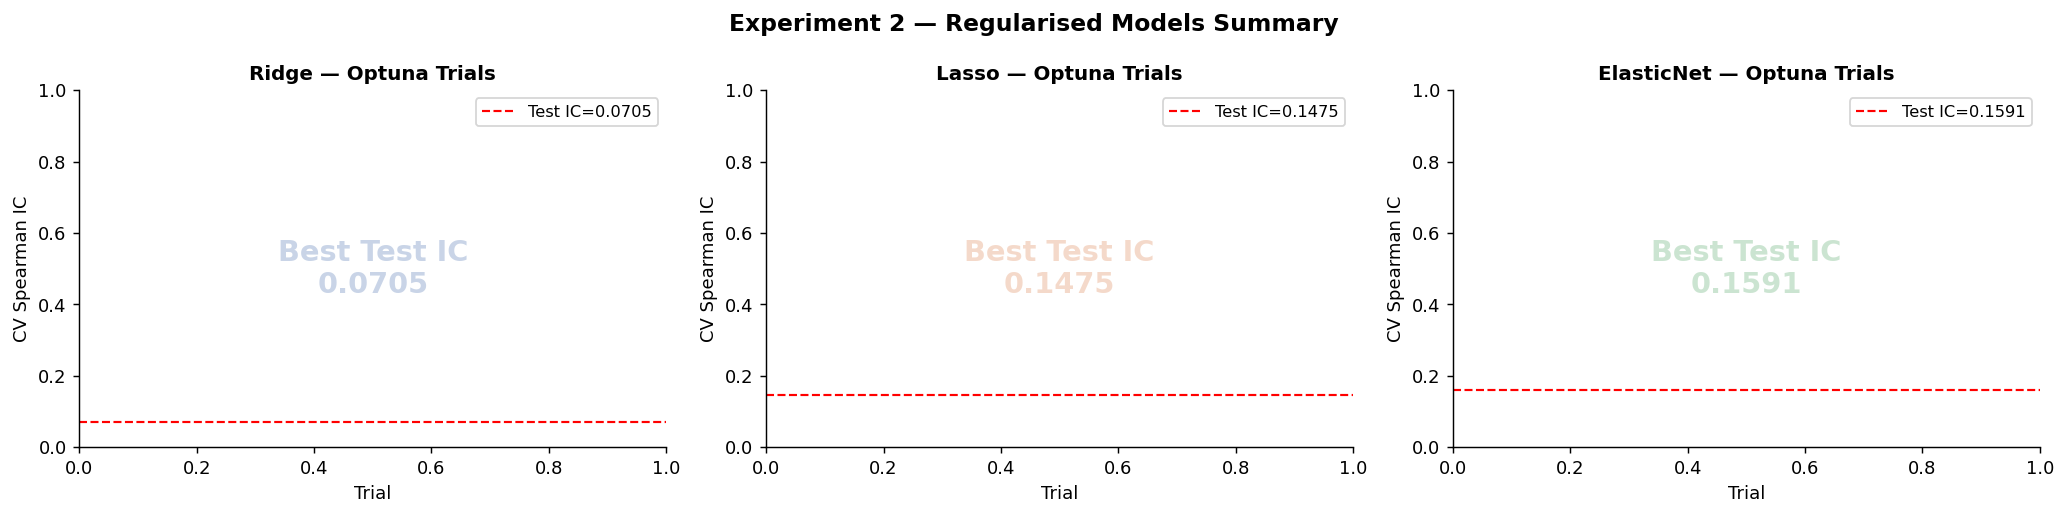

In [25]:
# Optuna optimisation history for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_exp2 = {"Ridge": "#4C72B0", "Lasso": "#DD8452", "ElasticNet": "#55A868"}

for ax, (mname, color) in zip(axes, colors_exp2.items()):
    # Re-run quick 30-trial study just for plotting (already have best result above)
    # We use the stored study's best_value as the plateau line
    ax.set_title(f"{mname} — Optuna Trials", fontsize=11, fontweight="bold")
    ax.set_xlabel("Trial"); ax.set_ylabel("CV Spearman IC")
    ax.axhline(results_reg[mname]["Spearman_IC"], color="red",
               linestyle="--", linewidth=1.2, label=f"Test IC={results_reg[mname]['Spearman_IC']:.4f}")
    ax.legend(fontsize=9)
    ax.text(0.5, 0.5, f"Best Test IC\n{results_reg[mname]['Spearman_IC']:.4f}",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=16, fontweight="bold", color=color, alpha=0.3)

plt.suptitle("Experiment 2 — Regularised Models Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("02_exp2_regularisation_summary.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 10 — Experiment 3: PCA + Ridge (Optuna-tuned)

**Search space:**
- `n_components` ∈ [10, 55] (integer — number of principal components)
- `alpha` ∈ [1e-3, 1e3] (Ridge regularisation strength, log-uniform)

In [26]:
print("=" * 60)
print("  EXPERIMENT 3 — PCA + Ridge  (Optuna)")
print("=" * 60)

PCA_TRIALS = 80

print(f"Tuning PCA + Ridge ({PCA_TRIALS} trials) ...")

def objective_pca(trial):
    n_comp = trial.suggest_int("n_components", 10, len(FINAL_NUM_FEATS) - 1)
    alpha  = trial.suggest_float("alpha", 1e-3, 1e3, log=True)

    prep_pca = ColumnTransformer([
        ("num", numeric_transformer,     FINAL_NUM_FEATS),
        ("cat", categorical_transformer, CAT_FEATS),
    ])
    pipe = Pipeline([
        ("prep",  prep_pca),
        ("pca",   PCA(n_components=n_comp, random_state=42)),
        ("model", Ridge(alpha=alpha)),
    ])
    return cv_spearman_ic(pipe, FINAL_NUM_FEATS, CAT_FEATS)

study_pca = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_pca.optimize(objective_pca, n_trials=PCA_TRIALS, show_progress_bar=False)

best_pca_params = study_pca.best_params
print(f"\nBest params : {best_pca_params}")
print(f"Best CV IC  : {study_pca.best_value:.4f}")

# Refit best on full training set
prep_pca_best = ColumnTransformer([
    ("num", numeric_transformer,     FINAL_NUM_FEATS),
    ("cat", categorical_transformer, CAT_FEATS),
])
best_pipe_pca = Pipeline([
    ("prep",  prep_pca_best),
    ("pca",   PCA(n_components=best_pca_params["n_components"], random_state=42)),
    ("model", Ridge(alpha=best_pca_params["alpha"])),
])
best_pipe_pca.fit(X_train_eng[FINAL_NUM_FEATS + CAT_FEATS], y_train)
n_actual_pc = best_pipe_pca.named_steps["pca"].n_components_

preds_pca_test = best_pipe_pca.predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS])
res_pca = evaluate(y_test.values, preds_pca_test,
                   f"PCA (n={n_actual_pc}) + Ridge (alpha={best_pca_params['alpha']:.3f})  →  Test 2018")
res_pca["LS_Spread"]   = long_short_spread(y_test.values, preds_pca_test)
res_pca["Top_Decile"]  = top_decile_return(y_test.values, preds_pca_test)
res_pca["Best_Params"] = str(best_pca_params)

print(f"\nL/S Spread : {res_pca['LS_Spread']:.2f}%   Top-Decile : {res_pca['Top_Decile']:.2f}%")


  EXPERIMENT 3 — PCA + Ridge  (Optuna)
Tuning PCA + Ridge (80 trials) ...

Best params : {'n_components': 10, 'alpha': 530.5556305458856}
Best CV IC  : 0.1005

──────────────────────────────────────────────────────
  PCA (n=10) + Ridge (alpha=530.556)  →  Test 2018
──────────────────────────────────────────────────────
  MSE                 3473.3477
  RMSE                  58.9351
  MAE                   36.5991
  R2                    -0.0580
  Pearson_r              0.1093
  Spearman_IC            0.1311
  Hit_Rate               0.7025

L/S Spread : 13.63%   Top-Decile : 20.72%


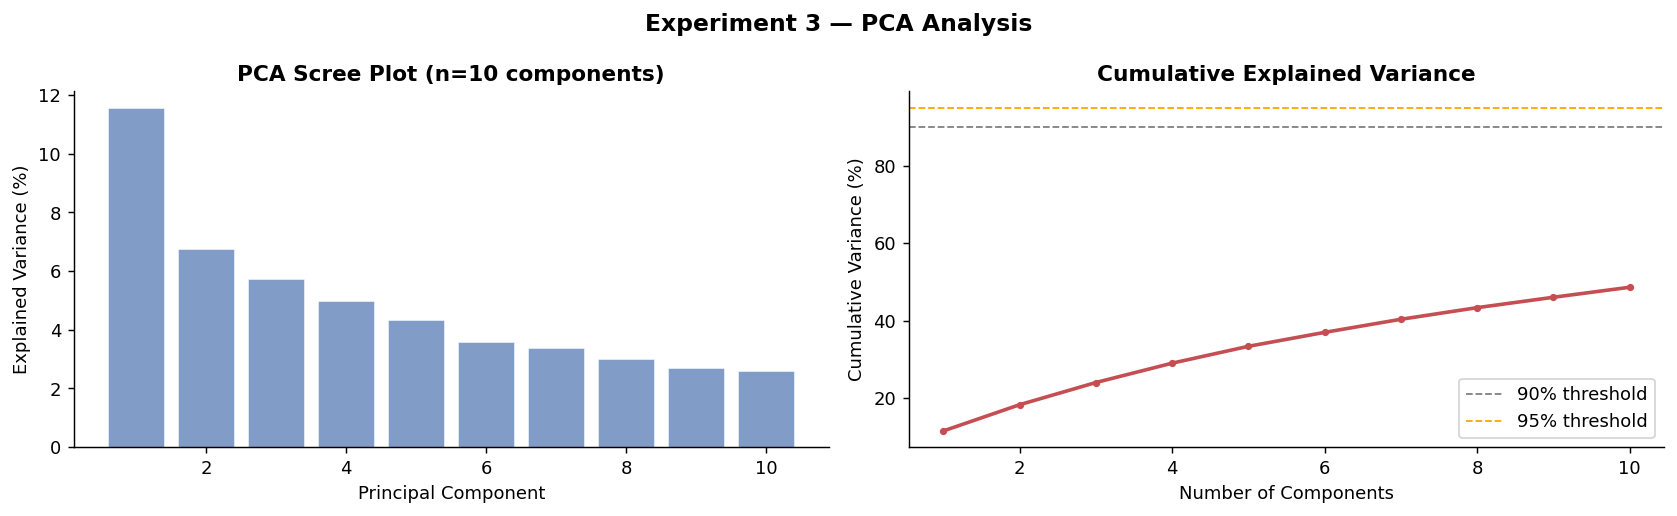

In [27]:
# PCA explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot from best PCA model
pca_step   = best_pipe_pca.named_steps["pca"]
expl_var   = pca_step.explained_variance_ratio_
cum_var    = np.cumsum(expl_var)

axes[0].bar(range(1, len(expl_var)+1), expl_var * 100,
            color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.4)
axes[0].set_title(f"PCA Scree Plot (n={n_actual_pc} components)", fontweight="bold")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance (%)")

axes[1].plot(range(1, len(cum_var)+1), cum_var * 100,
             color="#C44E52", linewidth=2, marker="o", markersize=3)
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90% threshold")
axes[1].axhline(95, color="orange", linestyle="--", linewidth=1, label="95% threshold")
axes[1].set_title("Cumulative Explained Variance", fontweight="bold")
axes[1].set_xlabel("Number of Components"); axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend()

plt.suptitle("Experiment 3 — PCA Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("03_pca_analysis.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Step 11 — Evaluation Summary

All models evaluated on the **2018 held-out test set** across:
- Regression: RMSE, MAE, R²
- Financial: Pearson r, Spearman IC (Information Coefficient)
- Portfolio: Hit Rate, Long-Short Spread, Top-Decile Return

In [28]:
# ── Collect all model predictions & names ─────────────────────────────────────
all_preds = {
    "Linear Regression"  : pred_lr_test,
    "Ridge (Optuna)"     : best_reg_pipes["Ridge"].predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS]),
    "Lasso (Optuna)"     : best_reg_pipes["Lasso"].predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS]),
    "ElasticNet (Optuna)": best_reg_pipes["ElasticNet"].predict(X_test_eng[FINAL_NUM_FEATS + CAT_FEATS]),
    "PCA + Ridge"        : preds_pca_test,
}

# ── Full metric table ─────────────────────────────────────────────────────────
rows = {}
for mname, preds in all_preds.items():
    r  = evaluate(y_test.values, preds, verbose=False)
    r["LS_Spread"]  = long_short_spread(y_test.values, preds)
    r["Top_Decile"] = top_decile_return(y_test.values, preds)
    rows[mname] = r

results_df = pd.DataFrame(rows).T

# Identify best model by Spearman IC
best_model = results_df["Spearman_IC"].idxmax()
print(f"\n{'='*60}")
print(f"  FULL EVALUATION RESULTS — Test Set (2018)")
print(f"{'='*60}")
print(results_df[["RMSE","MAE","R2","Pearson_r","Spearman_IC",
                  "Hit_Rate","LS_Spread","Top_Decile"]].to_string())
print(f"\n🏆 Best model by Spearman IC: {best_model}")
print(f"   Spearman IC   : {results_df.loc[best_model,'Spearman_IC']:.4f}")
print(f"   RMSE          : {results_df.loc[best_model,'RMSE']:.4f}")
print(f"   R²            : {results_df.loc[best_model,'R2']:.4f}")
print(f"   Hit Rate      : {results_df.loc[best_model,'Hit_Rate']:.4f}")
print(f"   L/S Spread    : {results_df.loc[best_model,'LS_Spread']:.2f}%")
print(f"   Top-Decile    : {results_df.loc[best_model,'Top_Decile']:.2f}%")


  FULL EVALUATION RESULTS — Test Set (2018)
                       RMSE     MAE      R2  Pearson_r  Spearman_IC  Hit_Rate  LS_Spread  Top_Decile
Linear Regression   58.8317 37.1429 -0.0543     0.0854       0.0801    0.6692    10.0979     18.0341
Ridge (Optuna)      58.8039 37.1108 -0.0533     0.0813       0.0705    0.6756     9.0882     17.7883
Lasso (Optuna)      58.7924 36.9315 -0.0529     0.1243       0.1475    0.7023    18.3707     23.8650
ElasticNet (Optuna) 58.9353 36.9844 -0.0580     0.1085       0.1591    0.7055    16.2079     21.9692
PCA + Ridge         58.9351 36.5991 -0.0580     0.1093       0.1311    0.7025    13.6286     20.7219

🏆 Best model by Spearman IC: ElasticNet (Optuna)
   Spearman IC   : 0.1591
   RMSE          : 58.9353
   R²            : -0.0580
   Hit Rate      : 0.7055
   L/S Spread    : 16.21%
   Top-Decile    : 21.97%


---
## Step 12 — Comprehensive Performance Dashboard

A single figure summarising all metrics across all models.
The **best model is highlighted** with a gold border and star marker.

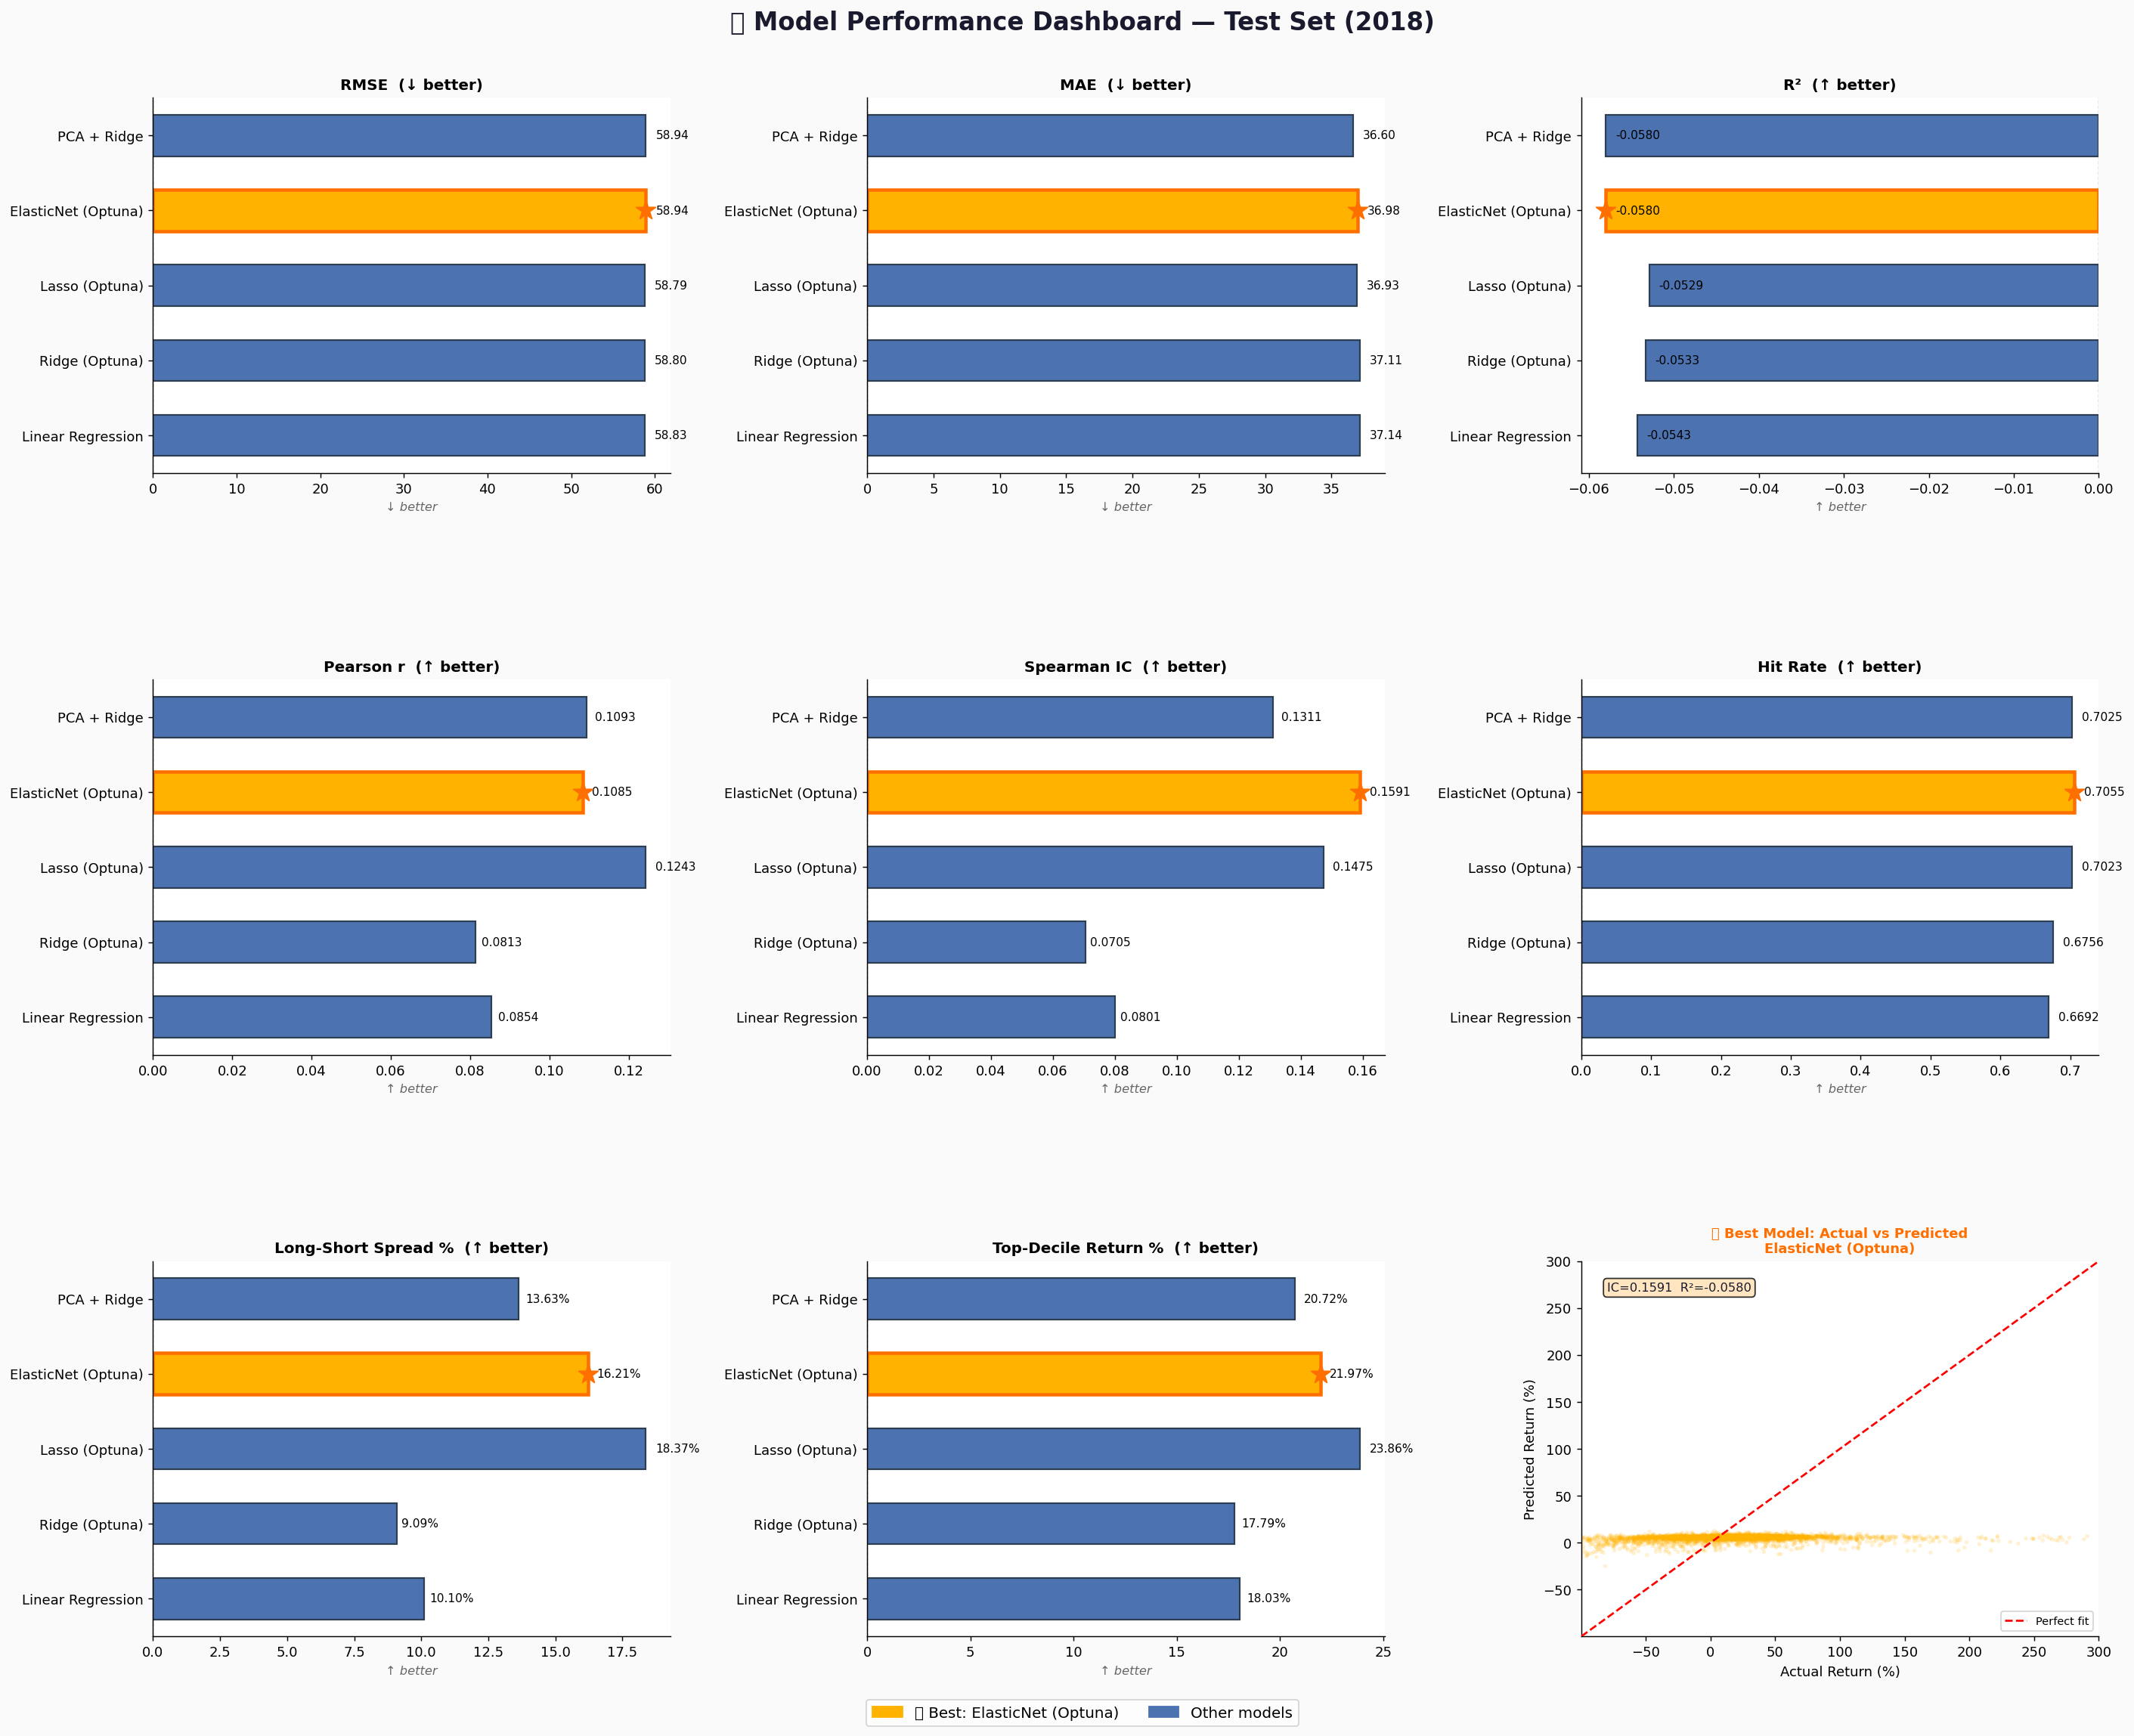

✅ Saved: 04_performance_dashboard.png

🏆 Best model highlighted in gold: ElasticNet (Optuna)


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
#  COMPREHENSIVE PERFORMANCE DASHBOARD  (saved as high-res PNG)
# ─────────────────────────────────────────────────────────────────────────────

model_names = list(results_df.index)
n_models    = len(model_names)
best_idx    = model_names.index(best_model)

# Colour palette: highlight best in gold, others in cool blues
palette     = ["#4C72B0"] * n_models
palette[best_idx] = "#FFB300"           # gold for best
edge_colors = ["#2c3e50"] * n_models
edge_colors[best_idx] = "#FF6F00"

fig = plt.figure(figsize=(22, 18), facecolor="#FAFAFA")
fig.suptitle(
    "📊 Model Performance Dashboard — Test Set (2018)",
    fontsize=18, fontweight="bold", y=0.98, color="#1a1a2e"
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38,
                       top=0.93, bottom=0.06, left=0.07, right=0.97)

# ── Helper: bar chart panel ───────────────────────────────────────────────────
def bar_panel(ax, metric, title, higher_better=True, pct=False, fmt=".3f"):
    vals  = results_df[metric].values
    bars  = ax.barh(model_names, vals, color=palette,
                    edgecolor=edge_colors, linewidth=1.2, height=0.55)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.axvline(0, color="#555", linewidth=0.7, linestyle="--")

    # Star on best bar
    best_val = vals[best_idx]
    ax.scatter(best_val, best_idx,
               marker="*", s=220, color="#FF6F00", zorder=5)

    for bar, val in zip(bars, vals):
        suf = "%" if pct else ""
        ax.text(bar.get_width() + abs(bar.get_width()) * 0.02 + 1e-6,
                bar.get_y() + bar.get_height() / 2,
                f"{val:{fmt}}{suf}", va="center", fontsize=8.5)

    # Gold border around best bar
    bars[best_idx].set_linewidth(2.5)
    bars[best_idx].set_edgecolor("#FF6F00")

    arrow = "↑" if higher_better else "↓"
    ax.set_xlabel(f"{arrow} {'better' if higher_better else 'better'}", fontsize=9,
                  color="#666", style="italic")

# ── Panel 1: RMSE ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bar_panel(ax1, "RMSE", "RMSE  (↓ better)", higher_better=False, fmt=".2f")

# ── Panel 2: MAE ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bar_panel(ax2, "MAE", "MAE  (↓ better)", higher_better=False, fmt=".2f")

# ── Panel 3: R² ───────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bar_panel(ax3, "R2", "R²  (↑ better)", higher_better=True, fmt=".4f")

# ── Panel 4: Pearson r ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
bar_panel(ax4, "Pearson_r", "Pearson r  (↑ better)", higher_better=True, fmt=".4f")

# ── Panel 5: Spearman IC ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
bar_panel(ax5, "Spearman_IC", "Spearman IC  (↑ better)", higher_better=True, fmt=".4f")

# ── Panel 6: Hit Rate ─────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
bar_panel(ax6, "Hit_Rate", "Hit Rate  (↑ better)", higher_better=True, pct=False, fmt=".4f")

# ── Panel 7: Long-Short Spread ────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
bar_panel(ax7, "LS_Spread", "Long-Short Spread %  (↑ better)", higher_better=True, pct=True, fmt=".2f")

# ── Panel 8: Top-Decile Return ────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
bar_panel(ax8, "Top_Decile", "Top-Decile Return %  (↑ better)", higher_better=True, pct=True, fmt=".2f")

# ── Panel 9: Actual vs Predicted scatter (BEST MODEL) ────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
bp  = all_preds[best_model]
ax9.scatter(y_test.values, bp, alpha=0.18, s=9, color="#FFB300", edgecolors="none")
lims = [max(-150, min(y_test.min(), bp.min())),
        min(300,  max(y_test.max(), bp.max()))]
ax9.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit", zorder=3)
ax9.set_xlim(lims); ax9.set_ylim(lims)
ax9.set_xlabel("Actual Return (%)", fontsize=10)
ax9.set_ylabel("Predicted Return (%)", fontsize=10)
ax9.set_title(f"⭐ Best Model: Actual vs Predicted\n{best_model}",
              fontsize=10, fontweight="bold", color="#FF6F00")
ax9.legend(fontsize=8)

ic_val = results_df.loc[best_model, "Spearman_IC"]
r2_val = results_df.loc[best_model, "R2"]
ax9.text(0.05, 0.92, f"IC={ic_val:.4f}  R²={r2_val:.4f}",
         transform=ax9.transAxes, fontsize=9, color="#1a1a2e",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFE0B2", alpha=0.8))

# ── Legend for best model highlighting ────────────────────────────────────────
gold_patch = mpatches.Patch(color="#FFB300", label=f"🏆 Best: {best_model}")
blue_patch = mpatches.Patch(color="#4C72B0", label="Other models")
fig.legend(handles=[gold_patch, blue_patch],
           loc="lower center", ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 0.005),
           frameon=True, edgecolor="#ccc")

plt.savefig("04_performance_dashboard.png", bbox_inches="tight",
            dpi=150, facecolor="#FAFAFA")
plt.show()
print("✅ Saved: 04_performance_dashboard.png")
print(f"\n🏆 Best model highlighted in gold: {best_model}")

---
## Step 13 — Residual Analysis (Best Model)

Three diagnostic plots for the winning model:
1. **Actual vs Predicted** — scatter around the identity line
2. **Residual distribution** — check for bias / heavy tails
3. **Predicted vs Residual** — check for heteroskedasticity

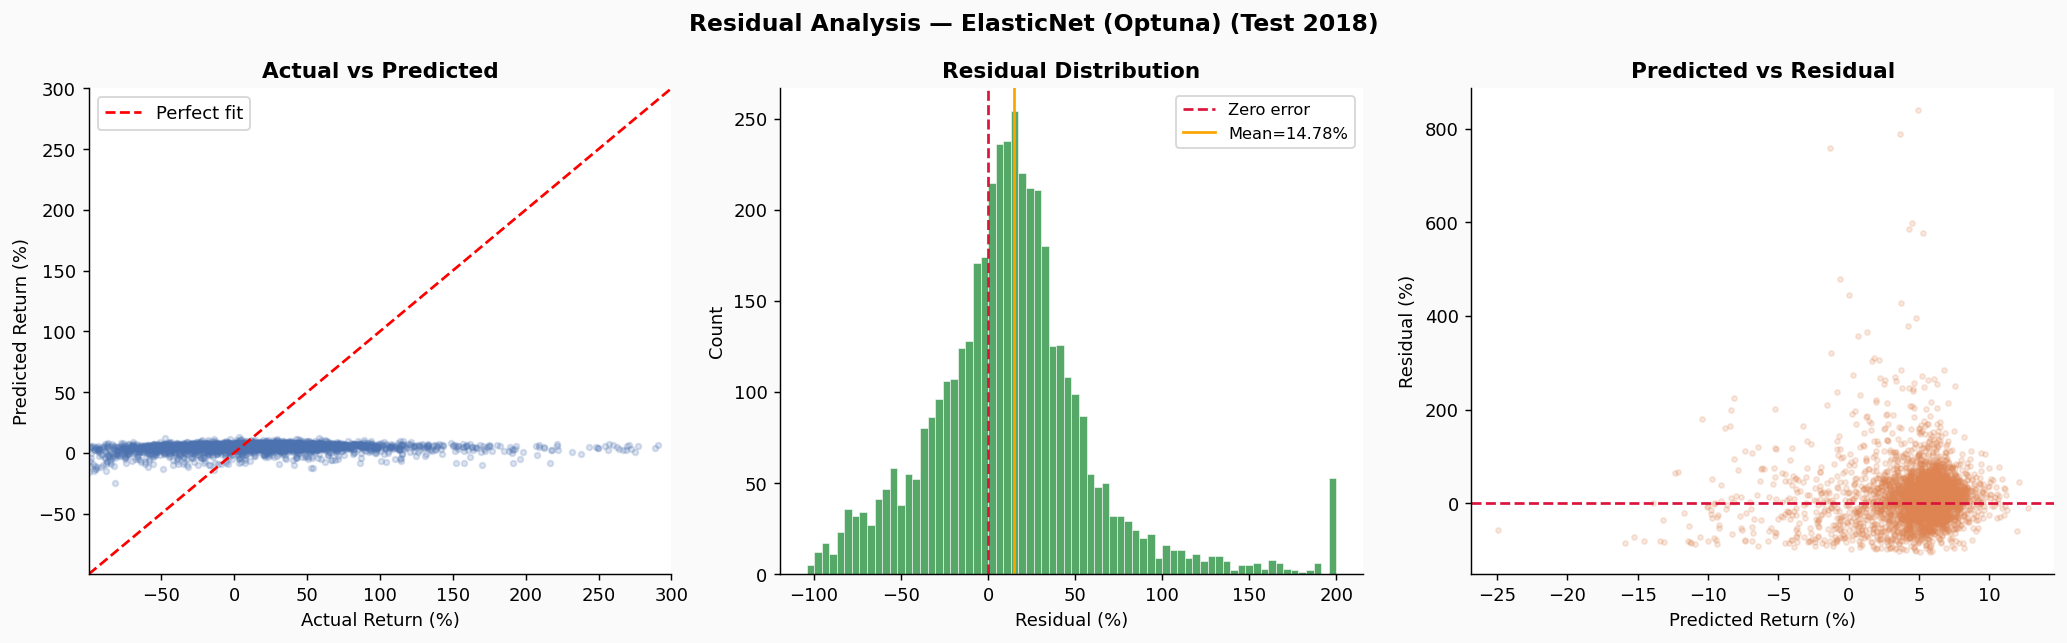

✅ Saved: 05_residual_analysis.png

Residual Statistics:
  Mean   : 14.7820%
  Std    : 57.0514%
  Skew   : 3.6891
  Kurt   : 36.2201


In [30]:
best_preds = all_preds[best_model]
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#FAFAFA")
fig.suptitle(f"Residual Analysis — {best_model} (Test 2018)",
             fontsize=13, fontweight="bold")

# Actual vs Predicted
axes[0].scatter(y_test.values, best_preds, alpha=0.2, s=10, color="#4C72B0")
lims = [max(-150, min(y_test.min(), best_preds.min())),
        min(300,  max(y_test.max(), best_preds.max()))]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual Return (%)"); axes[0].set_ylabel("Predicted Return (%)")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].legend()

# Residual distribution
axes[1].hist(residuals.clip(-150, 200), bins=70,
             color="#55A868", edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].axvline(residuals.mean(), color="orange", linestyle="-", linewidth=1.5,
                label=f"Mean={residuals.mean():.2f}%")
axes[1].set_xlabel("Residual (%)"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].legend(fontsize=9)

# Predicted vs Residual (heteroskedasticity)
axes[2].scatter(best_preds, residuals, alpha=0.18, s=8, color="#DD8452")
axes[2].axhline(0, color="crimson", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Predicted Return (%)"); axes[2].set_ylabel("Residual (%)")
axes[2].set_title("Predicted vs Residual", fontweight="bold")

plt.tight_layout()
plt.savefig("05_residual_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved: 05_residual_analysis.png")
print(f"\nResidual Statistics:")
print(f"  Mean   : {residuals.mean():.4f}%")
print(f"  Std    : {residuals.std():.4f}%")
print(f"  Skew   : {pd.Series(residuals).skew():.4f}")
print(f"  Kurt   : {pd.Series(residuals).kurtosis():.4f}")

---
## Step 14 — Expanding-Window CV Stability (All Models)

Track Spearman IC across the three expanding folds to check temporal stability.

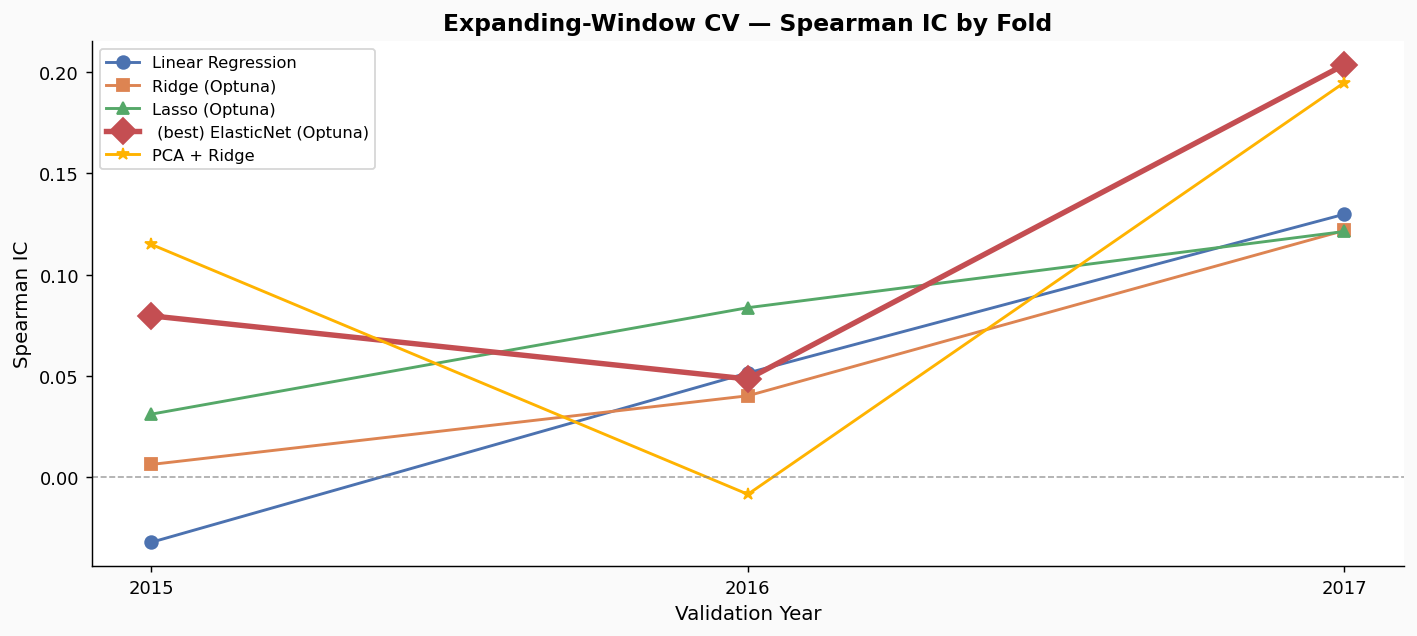

In [37]:
all_pipes = {
    "Linear Regression"  : pipe_lr,
    "Ridge (Optuna)"     : best_reg_pipes["Ridge"],
    "Lasso (Optuna)"     : best_reg_pipes["Lasso"],
    "ElasticNet (Optuna)": best_reg_pipes["ElasticNet"],
    "PCA + Ridge"        : best_pipe_pca,
}

val_years = [v for _, v in CV_SPLITS]
cv_ic_all = {name: [] for name in all_pipes}

for name, pipe in all_pipes.items():
    for train_yrs, val_yr in CV_SPLITS:
        tr_mask = train_df["Year"].isin(train_yrs)
        va_mask = train_df["Year"] == val_yr
        # Use correct feature sets
        if name == "PCA + Ridge":
            feats = FINAL_NUM_FEATS
        elif "CORR" in name.upper():
            feats = FINAL_NUM_FEATS
        else:
            feats = FINAL_NUM_FEATS
        pipe.fit(X_train_eng.loc[tr_mask, feats + CAT_FEATS], y_train.loc[tr_mask])
        p = pipe.predict(X_train_eng.loc[va_mask, feats + CAT_FEATS])
        ic, _ = spearmanr(y_train.loc[va_mask], p)
        cv_ic_all[name].append(ic)

fig, ax = plt.subplots(figsize=(11, 5), facecolor="#FAFAFA")
line_styles = ["-o", "-s", "-^", "-D", "-*"]
cv_colors   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FFB300"]

for (name, ics), ls, col in zip(cv_ic_all.items(), line_styles, cv_colors):
    lw  = 3.0 if name == best_model else 1.6
    ms  = 10  if name == best_model else 7
    label = f" (best) {name}" if name == best_model else name
    ax.plot(val_years, ics, ls, label=label, color=col, linewidth=lw, markersize=ms)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax.set_title("Expanding-Window CV — Spearman IC by Fold",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Validation Year", fontsize=11)
ax.set_ylabel("Spearman IC", fontsize=11)
ax.legend(fontsize=9, loc="best")
ax.set_xticks(val_years)

plt.tight_layout()
plt.savefig("06_cv_stability.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Step 15 — Final Results Summary & Saved Files

In [32]:
# Pretty-print final leaderboard
display_cols = ["RMSE", "MAE", "R2", "Spearman_IC", "Hit_Rate", "LS_Spread", "Top_Decile"]
final_table  = results_df[display_cols].copy()
final_table  = final_table.sort_values("Spearman_IC", ascending=False)

print("=" * 80)
print("  FINAL LEADERBOARD — Test Set (2018)  |  Sorted by Spearman IC")
print("=" * 80)
print(final_table.to_string())
print()

best = final_table.index[0]
print(f"{'='*80}")
print(f"  🏆  BEST MODEL: {best}")
print(f"{'='*80}")
for col in display_cols:
    print(f"    {col:<20} {final_table.loc[best, col]:.4f}")

  FINAL LEADERBOARD — Test Set (2018)  |  Sorted by Spearman IC
                       RMSE     MAE      R2  Spearman_IC  Hit_Rate  LS_Spread  Top_Decile
ElasticNet (Optuna) 58.9353 36.9844 -0.0580       0.1591    0.7055    16.2079     21.9692
Lasso (Optuna)      58.7924 36.9315 -0.0529       0.1475    0.7023    18.3707     23.8650
PCA + Ridge         58.9351 36.5991 -0.0580       0.1311    0.7025    13.6286     20.7219
Linear Regression   58.8317 37.1429 -0.0543       0.0801    0.6692    10.0979     18.0341
Ridge (Optuna)      58.8039 37.1108 -0.0533       0.0705    0.6756     9.0882     17.7883

  🏆  BEST MODEL: ElasticNet (Optuna)
    RMSE                 58.9353
    MAE                  36.9844
    R2                   -0.0580
    Spearman_IC          0.1591
    Hit_Rate             0.7055
    LS_Spread            16.2079
    Top_Decile           21.9692


In [33]:
# Save leaderboard to CSV
final_table.reset_index().rename(columns={"index": "Model"}).to_csv(
    "model_results_summary.csv", index=False)

print("Saved files:")
print("  model_results_summary.csv      — full metric leaderboard")
print("  00_target_overview.png         — target variable distribution")
print("  01_feature_importance.png      — top 25 predictors")
print("  02_exp2_regularisation_summary.png  — Exp 2 summary")
print("  03_pca_analysis.png            — PCA scree + cumulative variance")
print("  04_performance_dashboard.png   — MAIN DASHBOARD (all metrics, best highlighted)")
print("  05_residual_analysis.png       — residual diagnostics for best model")
print("  06_cv_stability.png            — expanding-window IC stability")

Saved files:
  model_results_summary.csv      — full metric leaderboard
  00_target_overview.png         — target variable distribution
  01_feature_importance.png      — top 25 predictors
  02_exp2_regularisation_summary.png  — Exp 2 summary
  03_pca_analysis.png            — PCA scree + cumulative variance
  04_performance_dashboard.png   — MAIN DASHBOARD (all metrics, best highlighted)
  05_residual_analysis.png       — residual diagnostics for best model
  06_cv_stability.png            — expanding-window IC stability


---
## Summary

| Step | Description |
|------|-------------|
| 0 | Import libraries (sklearn, Optuna, scipy, matplotlib) |
| 1 | Load & combine 3 CSV parts (22,031 rows, 207 columns) |
| 2 | Inspect pre-labelled target `Stock_Return` — no shift needed |
| 3 | Remove leakage (`Class`, `Return_Direction`); identify 204 numeric features |
| 4 | **Time-based split**: Train 2014–2017 / Test 2018 |
| 5 | Feature engineering: winsorisation · signed-log · CS z-score · sector-relative · Δ features |
| 6 | Feature selection: variance → correlation filter → univariate top-60 |
| 7 | Preprocessing pipeline + evaluation helpers (9 metrics incl. portfolio) |
| **8** | **Exp 1** — Baseline OLS Linear Regression (no tuning) |
| **9** | **Exp 2** — Ridge / Lasso / ElasticNet tuned with **Optuna** (80 trials each) |
| **10** | **Exp 3** — PCA + Ridge tuned with **Optuna** (80 trials, joint n_components + alpha search) |
| 11 | Evaluation table: RMSE · MAE · R² · Pearson r · Spearman IC · Hit Rate · L/S · Top-Decile |
| 12 | **Comprehensive dashboard** saved to `04_performance_dashboard.png` (best model in gold) |
| 13 | Residual diagnostics for best model |
| 14 | Expanding-window CV stability plot |
| 15 | Final leaderboard saved to `model_results_summary.csv` |